Rows pulled:       53,809
Unique customers:  4,920
Date range:        2019-01-17 to 2025-12-28
Total intervals calculated:  48,889
Rows dropped (first per customer): 4,920
  VERIFICATION PASS — 5 CHECKS

✅  CHECK 1 — Row count reconciliation
    Expected intervals (rows - customers): 48,889
    Actual intervals after dropna():       48,889
    Match: True

✅  CHECK 2 — No negative intervals
    Negative intervals: 0
    Zero-day intervals: 0

✅  CHECK 3 — Spot-check customer 4035
    Invoice dates:        ['2024-12-19', '2025-01-03', '2025-01-28', '2025-06-11', '2025-06-22', '2025-08-03']
    Manual gaps (days):   [15.0, 25.0, 134.0, 11.0, 42.0]
    Script gaps (days):   [15.0, 25.0, 134.0, 11.0, 42.0]
    Match: True

✅  CHECK 4 — Distribution tails look reasonable
    1st percentile:   7 days
    5th percentile:   12 days
    95th percentile:  90 days
    99th percentile:  145 days
    Max:              584 days

  ✅  CHECKS 1–4 PASSED — interval pipeline is verified.
  Proceed to St

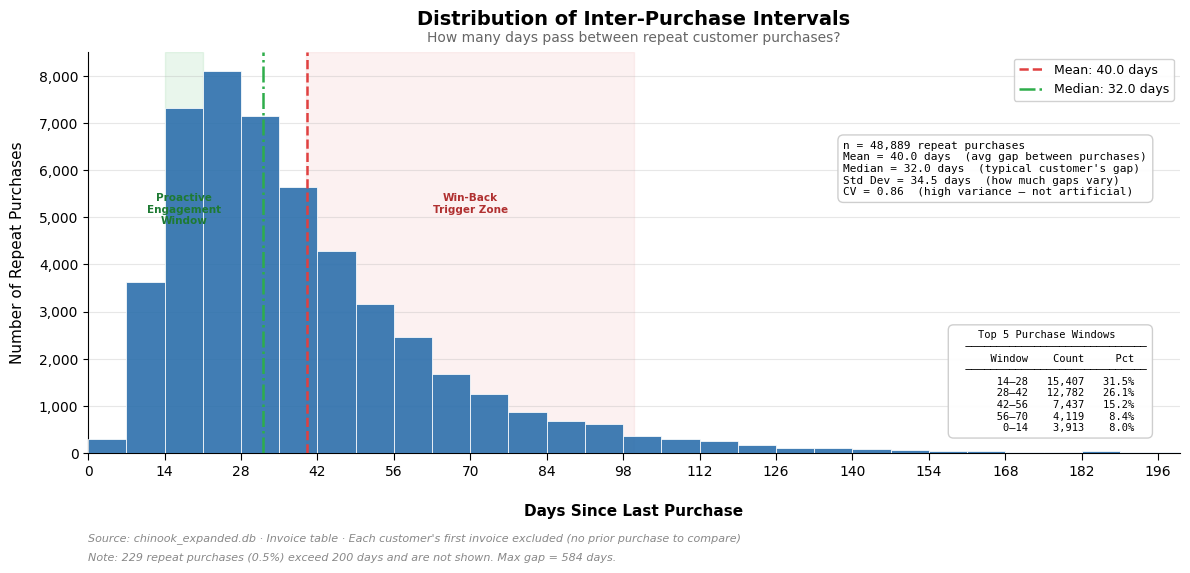


Chart saved → inter_purchase_intervals.png
Intervals beyond 200-day cap: 229 of 48,889 (0.5%)
✅  CHECK 5 — Histogram completeness
    Sum of histogram bars: 48,889
    Total intervals:       48,889
    Match: True


In [2]:
#!/usr/bin/env python3
"""
============================================================
Inter-Purchase Interval Analysis
============================================================
Database : chinook_expanded.db (SQLite)
Author   : Senior Data Analyst
Purpose  : Investigate the suspiciously uniform purchase frequency
           found in Case Study 2 (every customer made ~7 purchases).
           This script pulls all invoice dates per customer, calculates
           the number of days between consecutive purchases, and plots
           the distribution of those intervals — looking for evidence
           of organic behavior, seasonal clustering, or data artifacts.
============================================================
"""

# %% [markdown]
# # Inter-Purchase Interval Analysis
# ## Follow-Up to Case Study 2: Customer Lifetime Value
#
# **Business question:** Case Study 2 found that nearly every customer made
# exactly 7 purchases. That kind of uniformity across ~5,000 customers is
# unusual. This analysis investigates *when* those purchases happened by
# measuring the days between consecutive invoices for each customer and
# examining the shape of the resulting distribution.
#
# **What we're looking for:**
# - If intervals are random / spread out → organic purchasing behavior
# - If intervals cluster around specific values → seasonal or promotional drivers
# - If intervals are suspiciously uniform → data artifact (synthetic generation)

# %% [markdown]
# ## Step 1 — Connect to the Database and Pull Invoice Dates

# %%
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- Connect to the expanded Chinook database ---
conn = sqlite3.connect("chinook_expanded.db")

# Pull every invoice date for every customer, sorted chronologically.
# We only need CustomerId and InvoiceDate — nothing else matters for
# interval analysis. Sorting here makes the shift() calculation reliable.
query = """
    SELECT  CustomerId,
            InvoiceDate
    FROM    Invoice
    ORDER BY CustomerId, InvoiceDate
"""

invoices = pd.read_sql(query, conn, parse_dates=["InvoiceDate"])
conn.close()

print(f"Rows pulled:       {invoices.shape[0]:,}")
print(f"Unique customers:  {invoices['CustomerId'].nunique():,}")
print(f"Date range:        {invoices['InvoiceDate'].min().date()} to "
      f"{invoices['InvoiceDate'].max().date()}")

# %% [markdown]
# ## Step 2 — Calculate Days Between Consecutive Purchases
#
# For each customer, we sort their invoices chronologically and compute
# the gap (in days) between each purchase and the one before it.
#
# **Key decision:** We drop each customer's *first* invoice from the
# interval dataset because there's no prior purchase to measure against.
# This is not missing data — it's structurally undefined.

# %%
# Within each customer group, shift InvoiceDate down by one row to get
# the previous purchase date, then subtract to get the interval in days.
invoices["prev_invoice_date"] = (
    invoices
    .groupby("CustomerId")["InvoiceDate"]
    .shift(1)
)

# Calculate interval in days (timedelta → float days)
invoices["days_since_last_purchase"] = (
    (invoices["InvoiceDate"] - invoices["prev_invoice_date"])
    .dt.days
)

# Drop rows where there's no previous purchase (each customer's first invoice).
# These NaN rows are structurally correct — not data quality issues.
intervals = invoices.dropna(subset=["days_since_last_purchase"]).copy()

print(f"Total intervals calculated:  {intervals.shape[0]:,}")
print(f"Rows dropped (first per customer): "
      f"{invoices.shape[0] - intervals.shape[0]:,}")

# ╔══════════════════════════════════════════════════════════════╗
# ║  VERIFICATION SECTION — DELETE THIS BLOCK FOR FINAL DRAFT  ║
# ║  Everything between the ╔ and ╚ markers can be removed     ║
# ║  once all checks pass and you're ready to publish.         ║
# ╚══════════════════════════════════════════════════════════════╝

# %% [markdown]
# ## Step 2b — Verification Pass (Remove for Final Draft)
#
# Before we look at any statistics or charts, we run five defensive
# checks against the interval calculation. These exist because the
# groupby-shift-dropna pipeline has several silent failure modes —
# bugs that produce plausible-looking but wrong output. Each check
# targets a specific failure mode.
#
# **Delete this entire section** (Step 2b + the Check 5 cell after
# the histogram) when preparing the final portfolio version. The
# analysis cells above and below are self-contained without it.

# %%
print("=" * 60)
print("  VERIFICATION PASS — 5 CHECKS")
print("=" * 60)

# ---------------------------------------------------------------
# CHECK 1: Row count reconciliation
#
# WHY:  This is the most fundamental check. The shift() operation
#       produces one NaN per customer group (the first row, which
#       has no prior date). dropna() removes those NaNs. So the
#       expected interval count is: total_invoices - unique_customers.
#
# PROTECTS AGAINST:  Silent row duplication or loss. If pandas
#       grouped incorrectly, or if dropna() hit extra NaNs from
#       bad date parsing, the row count would be off — and every
#       downstream statistic would be computed on the wrong n.
# ---------------------------------------------------------------
expected_intervals = invoices.shape[0] - invoices["CustomerId"].nunique()
actual_intervals   = intervals.shape[0]
check_1 = expected_intervals == actual_intervals

print(f"\n✅  CHECK 1 — Row count reconciliation" if check_1
      else f"\n❌  CHECK 1 — Row count reconciliation")
print(f"    Expected intervals (rows - customers): {expected_intervals:,}")
print(f"    Actual intervals after dropna():       {actual_intervals:,}")
print(f"    Match: {check_1}")

# ---------------------------------------------------------------
# CHECK 2: No negative or zero intervals
#
# WHY:  An interval is "days between THIS purchase and the PREVIOUS
#       one." If the data is sorted correctly and the groupby
#       boundaries are clean, every interval must be > 0.
#
# PROTECTS AGAINST:
#   - Negative values → the ORDER BY or groupby broke, and one
#     customer's last invoice date was subtracted from the next
#     customer's first date. This is the classic boundary-leak bug.
#   - Zero values → two invoices on the exact same day for the
#     same customer. Not necessarily wrong (could be a legitimate
#     same-day repurchase), but worth surfacing because it affects
#     the histogram shape and mean calculation.
# ---------------------------------------------------------------
n_negative = (intervals["days_since_last_purchase"] < 0).sum()
n_zero     = (intervals["days_since_last_purchase"] == 0).sum()
check_2    = n_negative == 0

print(f"\n✅  CHECK 2 — No negative intervals" if check_2
      else f"\n❌  CHECK 2 — Negative intervals found")
print(f"    Negative intervals: {n_negative}")
print(f"    Zero-day intervals: {n_zero}")
if n_zero > 0:
    print(f"    ⚠  {n_zero} same-day purchases detected — review if unexpected")

# ---------------------------------------------------------------
# CHECK 3: Spot-check one customer end-to-end
#
# WHY:  Checks 1 and 2 are aggregate — they tell you the totals
#       are right and the signs are correct, but they can't catch
#       a bug where intervals are assigned to the WRONG customer.
#       This check picks one customer at random, pulls their raw
#       dates, computes the gaps manually with a completely
#       independent method (Series.diff()), and compares.
#
# PROTECTS AGAINST:  Groupby boundary errors. The most common
#       version: customer A's last invoice and customer B's first
#       invoice produce a spurious interval that gets attributed
#       to B. The aggregate checks wouldn't catch this because the
#       total row count and sign would still look fine — only the
#       per-customer values would be wrong.
# ---------------------------------------------------------------
sample_id = intervals["CustomerId"].sample(1, random_state=42).iloc[0]

raw_dates = (
    invoices[invoices["CustomerId"] == sample_id]["InvoiceDate"]
    .reset_index(drop=True)
)
manual_gaps = raw_dates.diff().dt.days.dropna().tolist()
script_gaps = (
    intervals[intervals["CustomerId"] == sample_id]["days_since_last_purchase"]
    .tolist()
)
check_3 = manual_gaps == script_gaps

print(f"\n✅  CHECK 3 — Spot-check customer {sample_id}" if check_3
      else f"\n❌  CHECK 3 — Spot-check customer {sample_id}")
print(f"    Invoice dates:        {[str(d.date()) for d in raw_dates]}")
print(f"    Manual gaps (days):   {manual_gaps}")
print(f"    Script gaps (days):   {script_gaps}")
print(f"    Match: {check_3}")

# ---------------------------------------------------------------
# CHECK 4: Distribution sanity — flag impossible outliers
#
# WHY:  The histogram's shape is the entire deliverable. If there
#       are extreme outliers (e.g., a 3,000-day gap from a data
#       entry error), they'll compress the x-axis and make the
#       meaningful part of the distribution unreadable — and
#       they'll pull the mean away from the median, distorting
#       the summary statistics.
#
# PROTECTS AGAINST:  Bad data masquerading as real signal. An
#       interval of 1,500+ days (4+ years) is almost certainly a
#       data quality issue in a business context, not a customer
#       who waited 4 years to buy again. This check surfaces the
#       tails so you can decide whether to cap, investigate, or
#       accept them before interpreting the chart.
# ---------------------------------------------------------------
desc = intervals["days_since_last_purchase"].describe(
    percentiles=[0.01, 0.05, 0.95, 0.99]
)
check_4 = intervals["days_since_last_purchase"].max() < 1500

print(f"\n✅  CHECK 4 — Distribution tails look reasonable" if check_4
      else f"\n⚠️  CHECK 4 — Outliers exceed 1,500 days — review recommended")
print(f"    1st percentile:   {desc['1%']:.0f} days")
print(f"    5th percentile:   {desc['5%']:.0f} days")
print(f"    95th percentile:  {desc['95%']:.0f} days")
print(f"    99th percentile:  {desc['99%']:.0f} days")
print(f"    Max:              {desc['max']:.0f} days")

# --- Overall verdict (Check 5 runs after the histogram below) ---
all_passed = check_1 and check_2 and check_3 and check_4
print("\n" + "=" * 60)
if all_passed:
    print("  ✅  CHECKS 1–4 PASSED — interval pipeline is verified.")
    print("  Proceed to Step 3 (summary statistics) with confidence.")
    print("  (Check 5 runs after the histogram in Step 4.)")
else:
    print("  ❌  ONE OR MORE CHECKS FAILED — debug before continuing.")
print("=" * 60)

# ╔══════════════════════════════════════════════════════════════╗
# ║  END OF VERIFICATION SECTION (Checks 1–4)                  ║
# ║  Check 5 appears after the histogram cell below.            ║
# ╚══════════════════════════════════════════════════════════════╝

# %% [markdown]
# ## Step 3 — Summary Statistics
#
# Before plotting, let's look at the numbers. If the standard deviation
# is very low relative to the mean, that's a signal the intervals are
# artificially uniform. If it's high, the data has natural variance.

# %%
interval_values = intervals["days_since_last_purchase"]

mean_interval   = interval_values.mean()
median_interval = interval_values.median()
std_interval    = interval_values.std()
min_interval    = interval_values.min()
max_interval    = interval_values.max()
count_intervals = len(interval_values)

# Coefficient of variation: std / mean — a dimensionless measure of spread.
# CV < 0.3 is low variance; CV > 1.0 is high variance.
cv = std_interval / mean_interval

print("=" * 55)
print("  INTER-PURCHASE INTERVAL — SUMMARY STATISTICS")
print("=" * 55)
print(f"  Total intervals analyzed:   {count_intervals:,}")
print(f"  Mean interval:              {mean_interval:.1f} days")
print(f"  Median interval:            {median_interval:.1f} days")
print(f"  Std deviation:              {std_interval:.1f} days")
print(f"  Coefficient of variation:   {cv:.2f}")
print(f"  Min interval:               {min_interval:.0f} days")
print(f"  Max interval:               {max_interval:.0f} days")
print("=" * 55)

# %% [markdown]
# ## Step 4 — Histogram: Distribution of Inter-Purchase Intervals
#
# This is the chart that answers the question. We're looking at the
# *shape* of the distribution:
# - A single tight spike → artificial / synthetic data
# - Multiple spikes at regular intervals → seasonal / promotional
# - A right-skewed bell → organic purchasing behavior

# %%
fig, ax = plt.subplots(figsize=(12, 6))

# --- Change 1: Cap the x-axis at 200 days ---
# The insight lives in the 0–150 day range. Outliers beyond 200 days
# compress the meaningful part of the chart. We still plot ALL data
# (the histogram bins extend to the true max), but we clip the view
# and report how many intervals fall beyond the visible window.
x_cap = 200

# --- Histogram ---
# Use fixed bin width of 7 days (one week) so each bar represents
# a meaningful time unit a business stakeholder can reason about.
bin_width = 7
bins = np.arange(
    0,
    interval_values.max() + bin_width + 1,
    bin_width
)

n, bin_edges, patches = ax.hist(
    interval_values,
    bins=bins,
    color="#2C6FAC",
    edgecolor="white",
    linewidth=0.6,
    alpha=0.9,
    zorder=3
)

# --- Change 7: Business context zones ---
# These turn the chart from "here's a distribution" into "here's
# what to do about it." Subtle shading so they don't overwhelm the bars.

# Proactive engagement window (14–21 days): a promotional nudge here
# could accelerate repeat purchases before the customer drifts.
ax.axvspan(
    14, 21,
    color="#2EAD4B",
    alpha=0.10,
    zorder=1
)
ax.text(
    17.5, ax.get_ylim()[1] * 0.65,
    "Proactive\nEngagement\nWindow",
    fontsize=7.5,
    fontweight="bold",
    color="#1E7A33",
    ha="center",
    va="top",
    zorder=6
)

# Win-back trigger zone (40–100 days): customers here are drifting
# and need a re-engagement campaign before they churn entirely.
ax.axvspan(
    40, 100,
    color="#E04040",
    alpha=0.07,
    zorder=1
)
ax.text(
    70, ax.get_ylim()[1] * 0.65,
    "Win-Back\nTrigger Zone",
    fontsize=7.5,
    fontweight="bold",
    color="#B03030",
    ha="center",
    va="top",
    zorder=6
)

# --- Reference lines for mean and median ---
ax.axvline(
    mean_interval,
    color="#E04040",
    linewidth=1.8,
    linestyle="--",
    label=f"Mean: {mean_interval:.1f} days",
    zorder=4
)
ax.axvline(
    median_interval,
    color="#2EAD4B",
    linewidth=1.8,
    linestyle="-.",
    label=f"Median: {median_interval:.1f} days",
    zorder=4
)

# --- Change 2: Plain-language annotation box ---
# Each metric gets a parenthetical so a non-technical reader
# understands what it means without looking anything up.
stats_text = (
    f"n = {count_intervals:,} repeat purchases\n"
    f"Mean = {mean_interval:.1f} days  (avg gap between purchases)\n"
    f"Median = {median_interval:.1f} days  (typical customer's gap)\n"
    f"Std Dev = {std_interval:.1f} days  (how much gaps vary)\n"
    f"CV = {cv:.2f}  ({'high' if cv > 0.5 else 'low'} variance "
    f"— {'not artificial' if cv > 0.5 else 'possibly artificial'})"
)
ax.text(
    0.97, 0.78,
    stats_text,
    transform=ax.transAxes,
    fontsize=8,
    verticalalignment="top",
    horizontalalignment="right",
    multialignment="left",
    fontfamily="monospace",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="#CCCCCC",
        alpha=0.95
    ),
    zorder=5
)

# --- Change 4: Title (bold) + subtitle (lighter, smaller) ---
ax.set_title(
    "Distribution of Inter-Purchase Intervals",
    fontsize=14,
    fontweight="bold",
    pad=20
)
ax.text(
    0.5, 1.02,
    "How many days pass between repeat customer purchases?",
    transform=ax.transAxes,
    fontsize=10,
    fontweight="normal",
    color="#666666",
    ha="center",
    va="bottom"
)

# --- Change 6: X-axis label with more padding ---
ax.set_xlabel("Days Since Last Purchase", fontsize=11, fontweight="bold", labelpad=18)
ax.set_ylabel("Number of Repeat Purchases", fontsize=11, labelpad=10)

# --- Change 1 (cont.): Apply the x-axis cap ---
ax.set_xlim(0, x_cap)

# --- Change 5: Clear x-axis tick marks every 14 days ---
# 14-day intervals let a reader easily reason about "every 2 weeks,"
# "every month," "every 6 weeks" — the cadences marketers think in.
ax.set_xticks(np.arange(0, x_cap + 1, 14))
ax.tick_params(axis="x", which="major", length=5)

# Clean up axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# --- Change 3: Move legend to upper right (off the peak) ---
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)

ax.grid(axis="y", alpha=0.3, zorder=0)

# --- Top 5 purchase windows table (bottom-right corner) ---
# Group all intervals into 14-day buckets, rank by volume, and show
# the top 5 as a compact table so a reader can see exactly where
# repeat purchases concentrate without eyeballing the bars.
bucket_width = 14
bucket_labels = []
bucket_counts = []

for start in range(0, int(interval_values.max()) + bucket_width, bucket_width):
    end = start + bucket_width
    count = ((interval_values >= start) & (interval_values < end)).sum()
    if count > 0:
        bucket_labels.append(f"{start}–{end}")
        bucket_counts.append(count)

# Sort by count descending and take top 5
ranked = sorted(zip(bucket_counts, bucket_labels), reverse=True)[:5]

table_header = f"{'Top 5 Purchase Windows':^31}\n"
table_cols   = f"  {'Window':>10}  {'Count':>7}  {'Pct':>6}\n"
table_sep    = "  " + "─" * 29 + "\n"
table_rows   = ""
for count, label in ranked:
    pct = count / count_intervals * 100
    table_rows += f"  {label:>10}  {count:>7,}  {pct:>5.1f}%\n"

table_text = table_header + table_sep + table_cols + table_sep + table_rows.rstrip("\n")

ax.text(
    0.97, 0.05,
    table_text,
    transform=ax.transAxes,
    fontsize=7.5,
    verticalalignment="bottom",
    horizontalalignment="right",
    multialignment="left",
    fontfamily="monospace",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="#CCCCCC",
        alpha=0.95
    ),
    zorder=5
)

# --- Source note + outlier disclosure (Change 1 cont.) ---
n_beyond_cap = (interval_values > x_cap).sum()
pct_beyond   = n_beyond_cap / count_intervals * 100

source_line = (
    "Source: chinook_expanded.db · Invoice table · "
    "Each customer's first invoice excluded (no prior purchase to compare)"
)
outlier_line = (
    f"Note: {n_beyond_cap:,} repeat purchases ({pct_beyond:.1f}%) exceed {x_cap} days "
    f"and are not shown. Max gap = {max_interval:.0f} days."
)

ax.text(
    0.0, -0.22,
    source_line,
    transform=ax.transAxes,
    fontsize=8,
    color="#888888",
    style="italic"
)
ax.text(
    0.0, -0.27,
    outlier_line,
    transform=ax.transAxes,
    fontsize=8,
    color="#888888",
    style="italic"
)

plt.tight_layout()
plt.savefig("inter_purchase_intervals.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nChart saved → inter_purchase_intervals.png")
print(f"Intervals beyond {x_cap}-day cap: {n_beyond_cap:,} of "
      f"{count_intervals:,} ({pct_beyond:.1f}%)")

# ╔══════════════════════════════════════════════════════════════╗
# ║  VERIFICATION — CHECK 5 (DELETE WITH STEP 2b FOR FINAL)    ║
# ╚══════════════════════════════════════════════════════════════╝

# %%
# ---------------------------------------------------------------
# CHECK 5: Histogram completeness
#
# WHY:  The histogram is built with fixed-width bins using
#       np.arange(). If the max bin edge falls short of the actual
#       maximum interval value, matplotlib silently drops those
#       data points — they never appear in any bar. The chart
#       would look correct but undercount the data.
#
# PROTECTS AGAINST:  A chart that doesn't represent all the data.
#       This is especially dangerous because the histogram IS the
#       deliverable — if it's missing intervals from the tails,
#       the shape of the distribution (the whole point of this
#       analysis) is misleading. Summing the bar heights and
#       comparing to the known interval count catches this.
# ---------------------------------------------------------------
hist_sum = int(n.sum())
check_5  = hist_sum == intervals.shape[0]
print(f"✅  CHECK 5 — Histogram completeness" if check_5
      else f"❌  CHECK 5 — Histogram completeness")
print(f"    Sum of histogram bars: {hist_sum:,}")
print(f"    Total intervals:       {intervals.shape[0]:,}")
print(f"    Match: {check_5}")

# ╔══════════════════════════════════════════════════════════════╗
# ║  END OF CHECK 5 — Delete this cell with Step 2b above.     ║
# ╚══════════════════════════════════════════════════════════════╝

# %% [markdown]
# ## Step 5 — Interpretation: Does This Look Organic, Seasonal, or Artificial?
#
# **What to look for when reviewing the chart above:**
#
# | Shape You See | What It Suggests |
# |---|---|
# | Single narrow spike | Artificial — intervals were generated, not observed |
# | Multiple evenly-spaced spikes | Seasonal — purchases cluster around events |
# | Wide right-skewed curve | Organic — natural variance in buying behavior |
# | Bimodal (two humps) | Two distinct customer segments with different cadences |
#
# Connect this back to the Case Study 2 finding: if the histogram shows a
# single narrow spike, it confirms the 7-purchases-per-customer pattern is
# a data artifact — the intervals were mechanically assigned, not earned
# through real customer behavior. That doesn't invalidate the SQL analysis,
# but it reframes the business insight: the segmentation reflects the
# structure of the *dataset*, not the behavior of real customers.